In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc

In [2]:
data = pd.read_parquet('../data/interim/meteorological_data_with_outages.parquet')

In [9]:
train_episode_fips_id, test_episode_fips_id = train_test_split(
    data.episode_fips_id.unique(), train_size=0.7, random_state=42
)

In [10]:
drop_cols = ['time', 'episode_fips_id', 'meteorological_current_datetime_val']

data_train = data[data.episode_fips_id.isin(train_episode_fips_id)].drop(drop_cols, axis=1)
data_test = data[data.episode_fips_id.isin(test_episode_fips_id)].drop(drop_cols, axis=1)

In [11]:
x_train, y_train = data_train.drop('outage_in_an_hour', axis=1), data_train.outage_in_an_hour
x_test, y_test = data_test.drop('outage_in_an_hour', axis=1), data_test.outage_in_an_hour

In [12]:
model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=12, 
    class_weight='balanced',
    ccp_alpha=0.001, 
)

In [13]:
model.fit(x_train, y_train)

RandomForestClassifier(ccp_alpha=0.001, class_weight='balanced', max_depth=12)

In [14]:
pred_train = pd.Series(model.predict_proba(x_train)[:, 1])
pred_train.index = x_train.index

In [15]:
pred_test = pd.Series(model.predict_proba(x_test)[:, 1])
pred_test.index = x_test.index

In [16]:
roc_auc_score(y_train, pred_train), roc_auc_score(y_test, pred_test)

(np.float64(0.8142100881629784), np.float64(0.7879075085378004))

In [17]:
pred_test

episode_fips_time_id
100298_36075_2015081813    0.268095
100298_36075_2015081814    0.260245
100298_36075_2015081815    0.273664
100298_36075_2015081816    0.337522
100298_36075_2015081817    0.406956
                             ...   
99962_34029_2015100109     0.513732
99962_34029_2015100110     0.512862
99962_34029_2015100111     0.503444
99962_34029_2015100112     0.478137
99962_34029_2015100113     0.468076
Length: 64936, dtype: float64

In [18]:
precision, recall, _ = precision_recall_curve(y_test, pred_test)
auc(recall, precision)

np.float64(0.08705579216180324)

In [20]:
precision, recall, _ = precision_recall_curve(y_train, pred_train)
auc(recall, precision)

np.float64(0.09795280390877237)

(array([ 6.,  5.,  5.,  2., 12.,  9.,  5.,  8., 11.,  6.,  4.,  9.,  6.,
         2., 10.,  7.,  7.,  3., 12.,  4.,  9.,  9.,  6.,  9.,  5.,  6.,
         7.,  8.,  6., 12.,  3.,  8., 10.,  3.,  6.,  6.,  5., 11., 11.,
         6., 12., 13.,  6.,  5., 15., 10., 11.,  7.,  8.,  8., 14., 20.,
        12., 21., 16., 14., 15., 11.,  9., 13., 11., 14., 17., 20., 17.,
        15., 15., 19., 19., 21., 17., 25., 25., 18., 11., 19., 22., 22.,
        39., 21., 22., 26., 25., 27., 24., 35., 36., 41., 36., 29., 23.,
        25., 34., 22., 34., 22., 25., 23., 35., 15.]),
 array([0.17379216, 0.18018843, 0.1865847 , 0.19298097, 0.19937724,
        0.2057735 , 0.21216977, 0.21856604, 0.22496231, 0.23135858,
        0.23775484, 0.24415111, 0.25054738, 0.25694365, 0.26333992,
        0.26973618, 0.27613245, 0.28252872, 0.28892499, 0.29532126,
        0.30171752, 0.30811379, 0.31451006, 0.32090633, 0.3273026 ,
        0.33369886, 0.34009513, 0.3464914 , 0.35288767, 0.35928394,
        0.3656802 , 0.3720

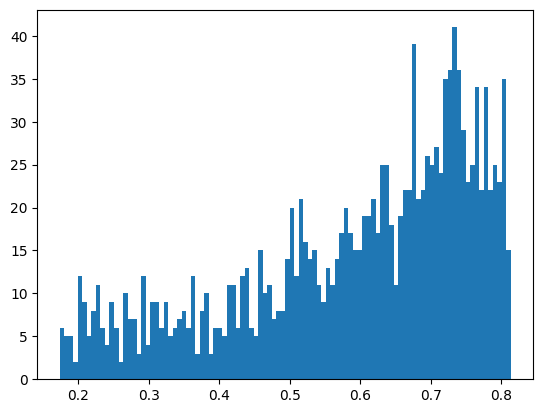

In [21]:
plt.hist(pred_test[y_test==1],bins=100)

(array([ 112., 1044., 1774., 1693., 1810., 1898., 1937., 1603., 1606.,
        1604., 1596., 1241., 1128., 1106., 1082., 1011.,  948.,  997.,
        1019., 1014.,  921.,  868.,  835.,  785.,  771.,  751.,  734.,
         667.,  645.,  637.,  624.,  602.,  605.,  604.,  521.,  554.,
         512.,  543.,  530.,  485.,  504.,  439.,  442.,  510.,  479.,
         447.,  469.,  455.,  480.,  522.,  512.,  520.,  482.,  550.,
         486.,  466.,  522.,  486.,  471.,  415.,  439.,  468.,  421.,
         455.,  488.,  470.,  432.,  424.,  441.,  408.,  454.,  492.,
         455.,  454.,  428.,  386.,  401.,  418.,  415.,  377.,  413.,
         389.,  402.,  416.,  441.,  451.,  369.,  374.,  300.,  270.,
         256.,  255.,  243.,  188.,  209.,  172.,  155.,  153.,  130.,
          85.]),
 array([0.16124769, 0.1677694 , 0.17429112, 0.18081283, 0.18733454,
        0.19385625, 0.20037797, 0.20689968, 0.21342139, 0.21994311,
        0.22646482, 0.23298653, 0.23950824, 0.24602996, 0.25255167

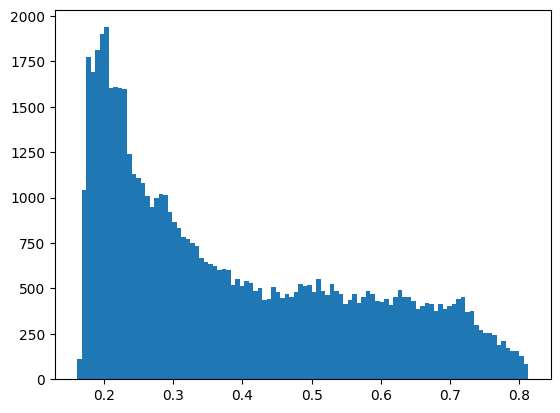

In [22]:
plt.hist(pred_test[y_test==0], bins=100)

In [54]:
response_var = pd.read_parquet('../data/interim/storm_outages_2014_2023.parquet')

In [22]:
sample_id = pd.Series(train_episode_fips_id).sample(1).iloc[0]
sample_data = data[data.episode_fips_id==sample_id]
sample_data['pred'] = pred_train

/tmp/ipykernel_3422/3169872164.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_data['pred'] = pred_train


In [23]:
sample_data

,time,T2M,ALLSKY_SFC_SW_DWN,PS,WS50M,ALLSKY_SFC_LW_DWN,WD50M,PRECTOTCORR,GWETPROF,CLRSKY_SFC_SW_DWN,...,Z0M,TOA_SW_DWN,RH2M,WS2M,CLRSKY_SFC_LW_DWN,DISPH,episode_fips_id,meteorological_current_datetime_val,outage_in_an_hour,pred
episode_fips_time_id,,,,,,,,,,,,,,,,,,,,,
166575_27131_2022041212,2022041212,13.58,136.15,96.62,18.42,362.98,124.9,5.08,0.57,810.58,...,0.03,1096.85,43.21,10.17,294.85,0.18,166575_27131,2022-04-12 12:00:00,0.0,0.419586
166575_27131_2022041213,2022041213,13.81,93.65,96.57,17.62,369.15,135.1,10.54,0.57,765.05,...,0.03,1048.25,49.58,9.89,298.95,0.18,166575_27131,2022-04-12 13:00:00,0.0,0.431009
166575_27131_2022041214,2022041214,14.04,73.85,96.48,15.73,374.30,139.6,15.37,0.57,658.25,...,0.03,938.20,58.61,8.95,304.75,0.18,166575_27131,2022-04-12 14:00:00,0.0,0.441154
166575_27131_2022041215,2022041215,13.98,39.40,96.35,14.61,373.98,136.7,10.09,0.57,521.20,...,0.03,774.25,66.74,8.14,308.42,0.18,166575_27131,2022-04-12 15:00:00,0.0,0.449171
166575_27131_2022041216,2022041216,13.75,17.80,96.22,13.76,377.88,130.4,10.59,0.57,351.45,...,0.03,567.58,74.38,7.56,313.50,0.18,166575_27131,2022-04-12 16:00:00,0.0,0.498527
166575_27131_2022041217,2022041217,13.47,43.28,96.10,13.24,377.38,126.1,13.07,0.57,172.60,...,0.03,332.30,82.40,7.07,317.15,0.18,166575_27131,2022-04-12 17:00:00,0.0,0.519415
166575_27131_2022041218,2022041218,13.13,9.43,95.97,13.32,348.17,124.0,12.49,0.57,28.27,...,0.03,87.60,89.89,6.95,325.27,0.18,166575_27131,2022-04-12 18:00:00,1.0,0.573043


In [57]:
pred_train.index.value_counts()

episode_fips_time_id
164119_06029_2021120823    2
108294_55079_2016090719    2
173075_06073_2022090202    2
159399_06029_2021071400    2
182909_48061_2023062311    2
                          ..
152231_06059_2020081904    1
152231_06059_2020081903    1
152231_06059_2020081902    1
152231_06059_2020081901    1
152231_06059_2020081909    1
Name: count, Length: 268453, dtype: int64

In [58]:
data.loc['164119_06029_2021120823']

,time,T2M,ALLSKY_SFC_SW_DWN,PS,WS50M,ALLSKY_SFC_LW_DWN,WD50M,PRECTOTCORR,GWETPROF,CLRSKY_SFC_SW_DWN,...,TQV,Z0M,TOA_SW_DWN,RH2M,WS2M,CLRSKY_SFC_LW_DWN,DISPH,episode_fips_id,meteorological_current_datetime_val,outage_in_an_hour
episode_fips_time_id,,,,,,,,,,,,,,,,,,,,,
164119_06029_2021120823,2021120823,8.91,0.0,92.91,1.78,302.33,233.9,0.84,0.55,0.0,...,20.32,0.1,0.0,90.7,0.5,273.62,0.5,164119_06029,2021-12-08 23:00:00,1.0
164119_06029_2021120823,2021120823,8.91,0.0,92.91,1.78,302.33,233.9,0.84,0.55,0.0,...,20.32,0.1,0.0,90.7,0.5,273.62,0.5,164119_06029,2021-12-08 23:00:00,0.0
